<a href="https://colab.research.google.com/github/malcolmlett/training-instrumentation-toolkit/blob/main/doc/blog-202503/gradient-collapse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms

## Example


In [27]:
# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

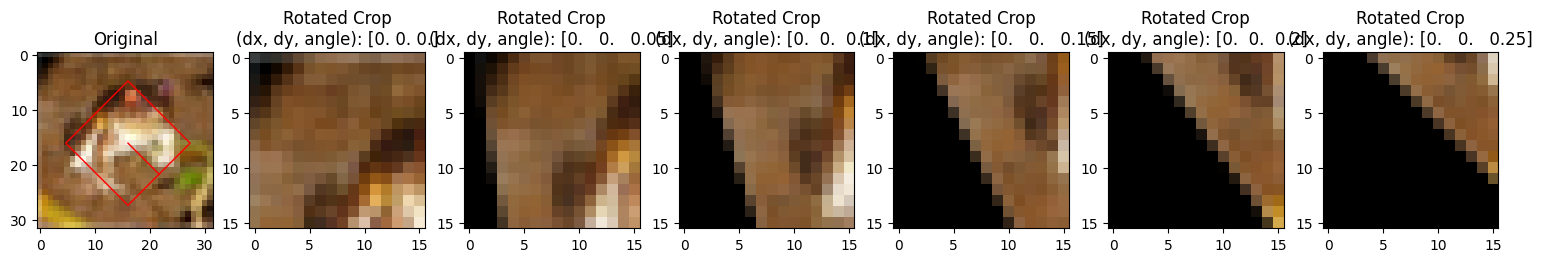

In [67]:
# image manipulation function
def rotated_crop(image, dx, dy, da):
    """
    Takes a 50% crop of the source image after applying a positional and angular
    offset relative to the image's centre.
    For example, (dx,dy,da) = (-0.25,0,0.5) will take a crop centred one quarter
    of the image width to the left from the source image centre and rotated
    45 degrees (50% of 180 in whichever direction the positive direction happens
    to take).
    Args:
      image: source image
      dx: float in range -0.5 .. +0.5 (fraction of width)
      dy: float in range -0.5 .. +0.5 (fraction of height)
      da: float in range -1.0 .. +1.0 (fraction of radians)
    Returns:
      cropped image
    """
    # Image dimensions
    img_height, img_width = image.shape[0], image.shape[1]
    img_centre_x = img_width // 2
    img_centre_y = img_height // 2
    crop_size = img_height // 2  # 50% of original size (16x16 for CIFAR-10)
    crop_centre_x = crop_size // 2
    crop_centre_y = crop_size // 2

    # Compute homography matrix from translation and rotation
    cos_val = tf.cos(da * np.pi)
    sin_val = tf.sin(da * np.pi)
    tx = dx * img_width
    ty = dy * img_height
    tx_adjusted = tx - (crop_centre_x - img_centre_x) * (1 - cos_val) + (crop_centre_y - img_centre_y) * sin_val
    ty_adjusted = ty - (crop_centre_y - img_centre_y) * (1 - cos_val) - (crop_centre_x - img_centre_x) * sin_val
    h_matrix = tf.stack([
        [cos_val, -sin_val, tx_adjusted],
        [sin_val, cos_val, ty_adjusted],
        [0.0, 0.0, 1.0]
    ])

    # Flatten to 8 parameters (last is 1)
    h_matrix = tf.reshape(h_matrix, [-1])[:-1]

    # Apply projective transform
    rotated_crop = tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.expand_dims(image, 0),  # Add batch dimension
        transforms=tf.expand_dims(h_matrix, 0),  # Add batch dimension
        output_shape=[crop_size, crop_size],
        interpolation='BILINEAR',
        fill_value=0.0,
        fill_mode='CONSTANT'
    )[0]  # Remove batch dimension

    return rotated_crop

def draw_crop_template(image, transform):
  dx, dy, da = transform
  centre_x = image.shape[1] * (0.5 + dx)
  centre_y = image.shape[0] * (0.5 + dy)
  width = image.shape[1] // 2
  height = image.shape[0] // 2
  radians = da * np.pi

  # draw a rectangle showing the outline of where the crop was taken from
  ax = plt.gca()
  rect = patches.Rectangle((centre_x - width/2, centre_y - height/2), width, height, linewidth=1, edgecolor='r', facecolor='none')
  t = transforms.Affine2D().rotate_deg_around(centre_x, centre_y, radians * 180 / np.pi)
  rect.set_transform(t + ax.transData)
  ax.add_patch(rect)

  # draw a rotated 0-degrees line to indicate the rotation.
  line_end_x = centre_x + width / 2
  line_end_y = centre_y
  rotated_endpoint = t.transform([(line_end_x, line_end_y)])[0]
  ax.plot([centre_x, rotated_endpoint[0]], [centre_y, rotated_endpoint[1]], color='r', linewidth=1)

def show_data_sample(inputs, output):
  (image, cropped) = inputs
  transform = output
  plt.figure(figsize=(10, 5))

  plt.subplot(1, 2, 1)
  plt.title("Original")
  plt.imshow(image)
  draw_crop_template(image, transform)

  plt.subplot(1, 2, 2)
  plt.title(f"Rotated Crop\n(dx, dy, angle): {transform}")
  plt.imshow(cropped)
  plt.show()

image = x_train[0]
transform = tf.constant(([0.0, 0.0, 0.15]))
cropped = rotated_crop(image, dx=transform[0], dy=transform[1], da=transform[2])
#show_data_sample((image, cropped), transform)

plt.figure(figsize=(15, 5), layout='constrained')


plt.subplot(1, 7, 1)
plt.title("Original")
plt.imshow(image)
draw_crop_template(image, tf.constant(([0.0, 0.0, 0.25])))
for i, da in enumerate([0.0, 0.05, 0.10, 0.15, 0.20, 0.25]):
  transform = tf.constant(([0.0, 0.0, da]))
  cropped = rotated_crop(image, dx=transform[0], dy=transform[1], da=transform[2])
  plt.subplot(1,7,i+2)
  plt.title(f"Rotated Crop\n(dx, dy, angle): {transform}")
  plt.imshow(cropped)
plt.show()



Original shape: (32, 32, 32, 3)
Rotated Crop shape: (32, 16, 16, 3)
Transformation shape: (32, 3)


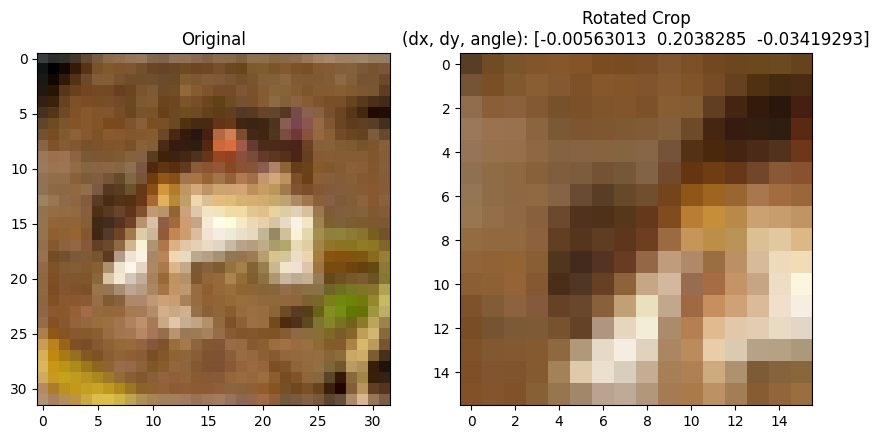

Time for 100 batches: 0.78 seconds


In [32]:
# pre-processing pipeline
def preprocess_image(image):
    # Generate random translation and rotation
    # - dx/dy in range -0.5..+0.5 (fraction of width/height)
    # - da    in range -1.0..+1.0 (radians)
    # - small stddev
    dx = tf.clip_by_value(tf.random.normal([], mean=0, stddev=0.5/4), -0.5, 0.5)
    dy = tf.clip_by_value(tf.random.normal([], mean=0, stddev=0.5/4), -0.5, 0.5)
    da = tf.clip_by_value(tf.random.normal([], mean=0, stddev=1.0/4), -1.0, 1.0)

    # Take rotated crop
    cropped = rotated_crop(image, dx, dy, da)

    # construct as input/output tuples
    transform = tf.stack([dx, dy, da])
    return (image, cropped), transform

# Create the dataset pipeline
train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(32).prefetch(tf.data.AUTOTUNE)

# Test and visualize
for (original, rotated_crop), transform in train_dataset.take(1):
    print("Original shape:", original.shape)         # [batch, 32, 32, 3]
    print("Rotated Crop shape:", rotated_crop.shape) # [batch, 16, 16, 3]
    print("Transformation shape:", transform.shape)  # [batch, 3]

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original[0])
    plt.subplot(1, 2, 2)
    plt.title(f"Rotated Crop\n(dx, dy, angle): {transform[0].numpy()}")
    plt.imshow(rotated_crop[0])
    plt.show()

# Optional: Time the pipeline
import time
start = time.time()
for _ in train_dataset.take(100):  # Process 100 batches
    pass
print(f"Time for 100 batches: {time.time() - start:.2f} seconds")